# Lab 5 - Multimedia RAG (text **and** images from a PDF)

**Dataset:** `minion-tech.pdf` - a 22-page business-analysis document for the fictional
"Gru's Enterprises". It has ordinary text **and 9 embedded images** (charts, tables,
figures). Labs 3 and 4 threw those images away. This lab keeps them.

**The core idea:** a *text* model cannot search or read an image, so we **convert each
image into text first** with a **multimodal** model, and index that text:

```
             +--> page text ----------------------------> text vector index --+
PDF ---------|                                                                |--> retrieve both --> answer + show images
             +--> each image --> multimodal model --> caption --> image vector index --+
```

At question time we retrieve relevant **text chunks** *and* relevant **image captions**,
the model answers from both, and the app displays the actual images it used.

| Piece | Choice |
|-------|--------|
| Text + page extraction | `PyPDFLoader` + `PyMuPDF` |
| Model (captions **and** answers) | Groq **`qwen/qwen3.8-27b`** - it is multimodal, so one model does both |
| Embeddings | `all-MiniLM-L6-v2` (local, free) |
| Vector store | two `FAISS` indexes: one for text, one for image captions |

> Note: Groq's `openai/gpt-oss-120b` / `-20b` are **text-only** - sending them an image
> returns a 400 error. `qwen/qwen3.8-27b` accepts images, which is why this lab uses it.


## Step 0 - Install

In [2]:
%pip install -q \ langchain langchain-community langchain-huggingface langchain-text-splitters \ faiss-cpu sentence-transformers groq pypdf pymupdf pillow gradio

## Step 1 - Groq API key

Free key: https://console.groq.com/keys . Colab: add a secret named `GROQ_API_KEY` (key icon, left sidebar).

In [3]:
import os

def load_key(name):
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v:
            print(f"{name}: from Colab secret"); return v
    except Exception:
        pass
    if os.getenv(name):
        print(f"{name}: from environment"); return os.environ[name]
    from getpass import getpass
    return getpass(f"Paste {name}: ")

GROQ_API_KEY = load_key("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

GROQ_API_KEY: from Colab secret


## Step 2 - One multimodal model for everything

`qwen/qwen3.8-27b` on Groq accepts **both** plain text and images. We use it to caption
images (Step 7) and to write the final answer (Step 9). The `chat()` helper takes an
OpenAI-style message list and has a short retry for transient rate limits.

In [4]:
import base64, io, time
from PIL import Image, ImageDraw
from groq import Groq

groq_client = Groq(api_key=GROQ_API_KEY)
MODEL = "qwen/qwen3.8-27b"

def _b64(img: Image.Image) -> str:
    buf = io.BytesIO(); img.convert("RGB").save(buf, format="JPEG")
    return base64.b64encode(buf.getvalue()).decode()

def chat(messages, tries=3) -> str:
    """One call to the model. `messages` is an OpenAI-style list; content may be a string
    or a list of text / image_url parts."""
    err = None
    for i in range(tries):
        try:
            r = groq_client.chat.completions.create(model=MODEL, messages=messages, temperature=0)
            txt = r.choices[0].message.content
            if txt and txt.strip():
                return txt.strip()
        except Exception as e:
            err = e
            print(f"   (retry {i + 1}/{tries}: {str(e)[:80]})")
        time.sleep(2 * (i + 1))
    raise RuntimeError(f"model did not respond: {err}")

# quick check that the model really can see an image
_t = Image.new("RGB", (240, 120), "white")
ImageDraw.Draw(_t).text((20, 50), "TEST 123", fill="black")
print("vision check ->", chat([{"role": "user", "content": [
    {"type": "text", "text": "What number is written in this image? Answer with just the number."},
    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{_b64(_t)}"}},
]}]))

vision check -> 123


## Step 3 - Get the PDF

In [5]:
PDF_NAME = "minion-tech.pdf"

def get_pdf(name):
    for path in (name, f"data/{name}", f"RAG_Labs/data/{name}"):
        if os.path.exists(path):
            print("Found:", path); return path
    try:
        from google.colab import files
        print(f"Choose {name}..."); up = files.upload()
        return list(up.keys())[0]
    except Exception:
        raise FileNotFoundError(name)

PDF_PATH = get_pdf(PDF_NAME)

Choose minion-tech.pdf...


Saving minion-tech.pdf to minion-tech.pdf


## Step 4 - Extract the page text

`PyPDFLoader` -> one `Document` per page.

In [6]:
from langchain_community.document_loaders import PyPDFLoader

pages = PyPDFLoader(PDF_PATH).load()
page_text = {p.metadata["page"]: " ".join(p.page_content.split()) for p in pages}
print(f"{len(pages)} pages of text extracted")
print("\nPage 0 preview:", page_text[0][:280], "...")

/tmp/ipykernel_884/1901523701.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


22 pages of text extracted

Page 0 preview: minion-tech.md 2024-01-06 1 / 22 Business Analysis Document Gru's Enterprises: Innovation in Cartoonish "Evil" Weaponry Address: 123 Villain Street, Villainville, EV123 Contact Information: Phone: 123-456-7890 Email: contact@grusenterprises.com Website: www.grusenterprises.com Pr ...


## Step 5 - The limitation: text-only RAG is blind to charts

Before adding images, let's prove we need them. Build a quick **text-only** index over the
page text (this is exactly Lab 3's pipeline) and ask a question whose answer lives *only in
a chart*:

> *"What were the R&D expenditure figures for 2021, 2022 and 2023?"*

Those year-by-year numbers appear **only inside the bar chart on page 17** - the page text
there literally just says "R&D Costs Chart". A text-only pipeline cannot answer this.

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

_text_only_index = FAISS.from_documents(
    RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100).split_documents(pages),
    embeddings,
)

CHART_Q = "What were the R&D expenditure figures for 2021, 2022 and 2023?"
_hits = _text_only_index.similarity_search(CHART_Q, k=4)
_ctx = "\n\n".join(f"(page {d.metadata.get('page')}) {d.page_content}" for d in _hits)
_prompt = ("Answer using ONLY this context. If it is not in the context, say so plainly.\n\n"
           f"Context:\n{_ctx}\n\nQuestion: {CHART_Q}\nAnswer:")

print("TEXT-ONLY retrieved pages:", [d.metadata.get("page") for d in _hits])
print("\nTEXT-ONLY answer:")
print(chat([{"role": "user", "content": _prompt}]))
print("\n^ It can only see the 2023 total from the P&L table - the 2021/2022 split is in the chart.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

TEXT-ONLY retrieved pages: [5, 17, 12, 3]

TEXT-ONLY answer:
The context does not contain the R&D expenditure figures for 2021, 2022, or 2023. It only mentions an annual R&D budget of $600,000 without specifying the year or providing a historical breakdown.

^ It can only see the 2023 total from the P&L table - the 2021/2022 split is in the chart.


## Step 6 - Extract the embedded images and render each page

- `PyMuPDF` pulls every embedded image out to `mm_images/`
- we also render each **full page** to `mm_pages/` - handy context to show the model where
  the image sits

Extracted 9 embedded images across 22 pages
mm_images/p0_i0.png (from page 0 )


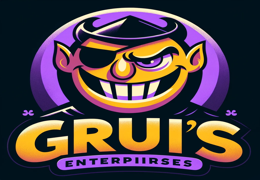

mm_images/p4_i0.png (from page 4 )


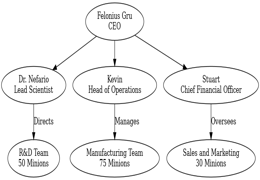

mm_images/p6_i0.png (from page 6 )


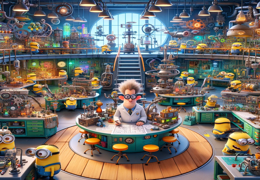

In [8]:
import pymupdf, shutil

IMG_DIR, PAGE_DIR = "mm_images", "mm_pages"
for d in (IMG_DIR, PAGE_DIR):
    shutil.rmtree(d, ignore_errors=True); os.makedirs(d)

doc = pymupdf.open(PDF_PATH)
images = []   # list of {"path", "page"}
for pno in range(len(doc)):
    doc[pno].get_pixmap(dpi=150).save(f"{PAGE_DIR}/page_{pno}.png")
    for idx, info in enumerate(doc[pno].get_images(full=True)):
        base = doc.extract_image(info[0])
        path = f"{IMG_DIR}/p{pno}_i{idx}.{base['ext']}"
        with open(path, "wb") as f:
            f.write(base["image"])
        images.append({"path": path, "page": pno})
doc.close()
print(f"Extracted {len(images)} embedded images across {len(pages)} pages")

from IPython.display import display
for im in images[:3]:
    print(im["path"], "(from page", im["page"], ")")
    display(Image.open(im["path"]).resize((260, 180)))

## Step 7 - Caption every image

For each image we send the model **the image + the text of the page it came from** so it
can name real labels and numbers instead of guessing. The caption is what we will actually
search over later.

In [9]:
CAPTION_INSTRUCTION = (
    "Describe this image from a business document in 2-4 sentences for search purposes. "
    "State what type of visual it is (chart, table, diagram, logo, photo), any title, "
    "axis labels, legend entries, and key numbers you can read. Use the page text below "
    "to get names and figures right. Do not invent anything.\n\nPAGE TEXT:\n{ptext}"
)

def caption_image(path, page):
    img = Image.open(path)
    return chat([{"role": "user", "content": [
        {"type": "text", "text": CAPTION_INSTRUCTION.format(ptext=page_text.get(page, "")[:1500])},
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{_b64(img)}"}},
    ]}])

for im in images:
    im["caption"] = caption_image(im["path"], im["page"])
    print(f"--- {im['path']} (page {im['page']}) ---")
    print(im["caption"], "\n")

--- mm_images/p0_i0.png (page 0) ---
This image is a logo for "Gru's Enterprises," featuring a cartoonish, villainous character with a yellow face, purple eyepatch, and a wide, toothy grin set against a purple circular background. Below the character's head, the text "GRUI'S" is displayed in large, bold, yellow-to-orange gradient letters, with the word "ENTERPIIRSES" written in smaller black capital letters on a purple banner underneath. The logo is presented in three views: a full shot, a close-up of the character's eye and ear, and a close-up of the text. 

--- mm_images/p4_i0.png (page 4) ---
This image is an organizational chart (diagram) illustrating the company's structure. At the top is "Felonius Gru, CEO," who has three direct reports: "Dr. Nefario, Lead Scientist," "Kevin, Head of Operations," and "Stuart, Chief Financial Officer." Each of these three leaders oversees a specific team: Dr. Nefario directs the "R&D Team" of 50 Minions, Kevin manages the "Manufacturing Team" of 7

## Step 8 - Build two FAISS indexes

- **text index** - the page text, split into chunks
- **image index** - one entry per image *caption*, with the image file path kept in metadata

Two separate indexes so we can pull a fixed number of each at question time.

In [10]:
from langchain_core.documents import Document

splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100)
text_docs = splitter.split_documents(pages)
text_index = FAISS.from_documents(text_docs, embeddings)

image_docs = [
    Document(page_content=im["caption"], metadata={"path": im["path"], "page": im["page"]})
    for im in images
]
image_index = FAISS.from_documents(image_docs, embeddings)

print(f"text index : {text_index.index.ntotal} chunks")
print(f"image index: {image_index.index.ntotal} captions")

text index : 33 chunks
image index: 9 captions


## Step 9 - The multimedia RAG function

1. retrieve top **text** chunks
2. retrieve top **image captions**
3. build one context with both, numbered `[Image 0]`, `[Image 1]`, ...
4. ask the model for a JSON answer: the text answer **and** which image numbers are worth showing
5. return the answer + the file paths of those images

QUESTION: What does the document say about revenue or financial projections, and is there a chart?

STEP 1  text chunks retrieved:
   (page 12) and efficiency.
Return on Investment Projections
With this investment, we project a 25% in...
   (page 7) and novelty sectors. Our competitive edge lies in our brand's recognizability and the unpa...
   (page 3) weaponry.
Key Financial Highlights
Total Revenue (2023): $4.2 million
Gross Profit Margin:...
   (page 16) Operating Income $200,000
Other Expenses
Interest Expense $100,000
Total Other Expenses $1...

STEP 2  image captions retrieved:
   [Image 0] (page 17) This image displays a vertical bar chart titled "R&D Expenditure (USD)" illustrating resea...
   [Image 1] (page 19) This image displays a pie chart titled "Purchases (USD)" that illustrates the distribution...
   [Image 2] (page 4) This image is an organizational chart (diagram) illustrating the company's structure. At t...

STEP 3-4  model JSON reply:
   {
"answer": "The document 

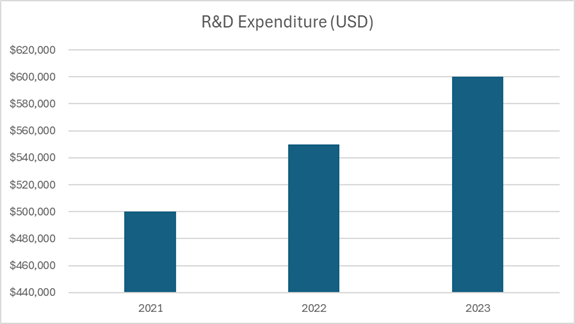

In [11]:
import json, re

MM_PROMPT = """Answer the QUESTION using the TEXT PASSAGES and IMAGE DESCRIPTIONS below.
If the answer is not there, say so.

TEXT PASSAGES:
{textblock}

IMAGE DESCRIPTIONS:
{imageblock}

QUESTION: {question}

Reply with ONLY valid JSON, no other text:
{{"answer": "<your answer>", "images_to_show": [<the [Image N] numbers that support the answer, or empty list>]}}"""

def multimedia_rag(question, k_text=4, k_image=3, verbose=True):
    text_hits = text_index.similarity_search(question, k=k_text)
    image_hits = image_index.similarity_search(question, k=k_image)

    textblock = "\n\n".join(f"(page {d.metadata.get('page')}) {d.page_content}" for d in text_hits) or "(none)"
    imageblock = "\n".join(f"[Image {i}] (page {d.metadata['page']}) {d.page_content}"
                            for i, d in enumerate(image_hits)) or "(none)"

    prompt_text = MM_PROMPT.format(textblock=textblock, imageblock=imageblock, question=question)
    raw = chat([{"role": "user", "content": prompt_text}])
    cleaned = re.sub(r"```(json)?", "", raw).strip()
    m = re.search(r"\{.*\}", cleaned, re.DOTALL)
    try:
        parsed = json.loads(m.group(0) if m else cleaned)
    except Exception:
        parsed = {"answer": raw, "images_to_show": []}

    idxs = [i for i in parsed.get("images_to_show", []) if isinstance(i, int) and 0 <= i < len(image_hits)]
    shown = [image_hits[i].metadata["path"] for i in idxs]

    if verbose:
        print("QUESTION:", question)
        print("\nSTEP 1  text chunks retrieved:")
        for d in text_hits:
            print(f"   (page {d.metadata.get('page')}) {d.page_content[:90]}...")
        print("\nSTEP 2  image captions retrieved:")
        for i, d in enumerate(image_hits):
            print(f"   [Image {i}] (page {d.metadata['page']}) {d.page_content[:90]}...")
        print("\nSTEP 3-4  model JSON reply:\n  ", cleaned)
        print("\nANSWER:", parsed.get("answer"))
        print("IMAGES TO SHOW:", shown)

    return {"answer": parsed.get("answer", raw), "images": shown,
            "text_hits": text_hits, "image_hits": image_hits}

out = multimedia_rag("What does the document say about revenue or financial projections, and is there a chart?")
for p in out["images"]:
    display(Image.open(p))

### Re-ask the Step 5 question - the one text-only RAG failed

Same `CHART_Q` as the limitation demo. Now that the bar chart has a searchable caption, the
answer (and the chart itself) come back.

QUESTION: What were the R&D expenditure figures for 2021, 2022 and 2023?

STEP 1  text chunks retrieved:
   (page 5) occasions.
These products, while playful, incorporate advanced technology and innovative d...
   (page 17) minion-tech.md 2024-01-06
18 / 22
Tables
R&D Costs: Breakdown of annual research and devel...
   (page 12) and efficiency.
Return on Investment Projections
With this investment, we project a 25% in...
   (page 3) weaponry.
Key Financial Highlights
Total Revenue (2023): $4.2 million
Gross Profit Margin:...

STEP 2  image captions retrieved:
   [Image 0] (page 17) This image displays a vertical bar chart titled "R&D Expenditure (USD)" illustrating resea...
   [Image 1] (page 19) This image displays a pie chart titled "Purchases (USD)" that illustrates the distribution...
   [Image 2] (page 4) This image is an organizational chart (diagram) illustrating the company's structure. At t...

STEP 3-4  model JSON reply:
   {
  "answer": "The R&D expenditure figures were $500

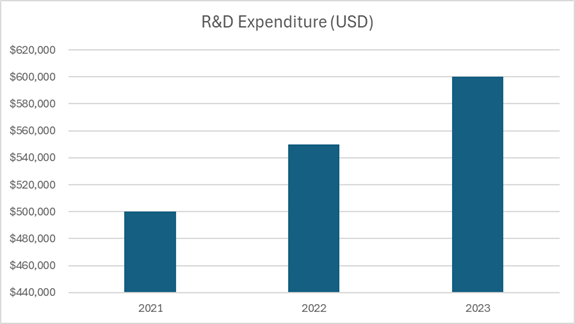

In [12]:
out2 = multimedia_rag(CHART_Q)
for p in out2["images"]:
    display(Image.open(p))

## Step 10 - Gradio app

Answer on the left, the images the model chose in a gallery, and the retrieved text + captions in accordions.

In [13]:
import gradio as gr

def mm_ui(question):
    if not question.strip():
        return "", [], "", ""
    out = multimedia_rag(question, verbose=False)
    gallery = [Image.open(p) for p in out["images"]]
    text_dump = "\n\n".join(f"(page {d.metadata.get('page')}) {d.page_content}" for d in out["text_hits"])
    cap_dump = "\n\n".join(f"[Image {i}] (page {d.metadata['page']})\n{d.page_content}"
                             for i, d in enumerate(out["image_hits"]))
    return out["answer"], gallery, text_dump, cap_dump

with gr.Blocks(title="Lab 5 - Multimedia RAG") as demo:
    gr.Markdown("# Lab 3 - Multimedia PDF RAG\nAsk about the text **or** the charts/figures in minion-tech.pdf.")
    q = gr.Textbox(label="Question", value="Is there a chart of revenue or costs? What does it show?")
    btn = gr.Button("Ask", variant="primary")
    ans = gr.Textbox(label="Answer", lines=5)
    gallery = gr.Gallery(label="Images the model used", columns=3, height=300)
    with gr.Accordion("Retrieved text chunks", open=False):
        tbox = gr.Textbox(label="", lines=10)
    with gr.Accordion("Retrieved image captions", open=False):
        cbox = gr.Textbox(label="", lines=10)
    gr.Examples([
        "Is there a chart of revenue or costs? What does it show?",
        "What were the R&D expenditure figures for 2021, 2022 and 2023?",
        "What does the org chart show about team sizes?",
        "What does the company logo look like?",
    ], inputs=q)
    btn.click(mm_ui, q, [ans, gallery, tbox, cbox])

demo.launch(debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0eed52e611cbaa6efe.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Recap

- **The limitation (Step 5):** text-only RAG cannot answer a question whose facts live only
  in a chart or figure - we proved it on the R&D expenditure numbers.
- **The fix:** a text model can't search an image, so we **turn each image into a searchable
  caption** with a *multimodal* model *at indexing time* (once), not at question time.
- Two FAISS indexes (text + captions) let us always bring back some of each.
- The model returns which images actually support its answer, and the app shows them.
- One model (`qwen/qwen3.8-27b`) did both jobs here because it is multimodal; a text-only
  model like `gpt-oss-120b` would need a separate vision model for the captioning step.

### Exercises
1. In Step 7, also pass the full-page render (`mm_pages/page_N.png`) as a second image to
   `caption_image`. Do the captions get more accurate?
2. Raise `k_image` to 5 in Step 9. Does the model start showing irrelevant images?
3. Ask a purely text question ("who prepared this document?"). Does `images_to_show`
   correctly come back empty?
